## A6c - Merge CME and coronal-hole features

This notebook merges CME and coronal-hole features into a single fixed 3h solar-origin timeline.

### Inputs
- `Data/processed/solar_origin_cme_features.parquet`
- `Data/processed/solar_origin_ch_features.parquet`

### Processing
- Outer-merge on `timestamp_utc` and enforce a uniform 3h cadence.
- Missingness policy:
  - CME counts -> 0
  - CH area/persistence -> 0
  - Means/centroids -> forward-fill
- Adds missingness flags for select CH fields.

### Output
- `Data/processed/solar_origin_features.parquet`


In [29]:
import pandas as pd
from pathlib import Path

CME_PATH = Path('../../Data/processed/solar_origin_cme_features.parquet')
CH_PATH = Path('../../Data/processed/solar_origin_ch_features.parquet')
OUT_PATH = Path('../../Data/processed/solar_origin_features.parquet')
CADENCE = '3h'

if not CME_PATH.exists():
    raise FileNotFoundError(f'Cannot find {CME_PATH}')
if not CH_PATH.exists():
    raise FileNotFoundError(f'Cannot find {CH_PATH}')

cme = pd.read_parquet(CME_PATH)
ch = pd.read_parquet(CH_PATH)

cme['timestamp_utc'] = pd.to_datetime(cme['timestamp_utc'], utc=True)
ch['timestamp_utc'] = pd.to_datetime(ch['timestamp_utc'], utc=True)

merged = (pd.merge(cme, ch, on='timestamp_utc', how='outer')
          .sort_values('timestamp_utc')
          .reset_index(drop=True))

# Fill CME counts with 0 if missing
for col in ['cme_count', 'cme_halo_count']:
    if col in merged.columns:
        merged[col] = merged[col].fillna(0).astype(int)

# Fill CH persistence/area with 0 if missing
for col in ['coronal_hole_area_total', 'coronal_hole_persistence_days']:
    if col in merged.columns:
        merged[col] = merged[col].fillna(0)

# Forward-fill mean signals (optional)
mean_cols = [c for c in merged.columns if c.endswith('_mean') or c.endswith('_max')]
merged[mean_cols] = merged[mean_cols].ffill()

# Build full grid to enforce cadence
start_grid = merged['timestamp_utc'].min().floor(CADENCE)
end_grid = merged['timestamp_utc'].max().ceil(CADENCE)
full_idx = pd.date_range(start_grid, end_grid, freq=CADENCE, tz='UTC')

out = pd.DataFrame(index=full_idx)
out = out.join(merged.set_index('timestamp_utc'))

# Apply missingness rules on the enforced grid
for col in ['cme_count', 'cme_halo_count']:
    if col in out.columns:
        out[col] = out[col].fillna(0).astype(int)
for col in ['coronal_hole_area_total', 'coronal_hole_persistence_days']:
    if col in out.columns:
        out[col] = out[col].fillna(0)

mean_cols = [c for c in out.columns if c.endswith('_mean') or c.endswith('_max')]
out[mean_cols] = out[mean_cols].ffill()

out = out.reset_index().rename(columns={'index': 'timestamp_utc'})

# --- Step 1 checks ---
# strictly monotonic time
is_monotonic = out['timestamp_utc'].is_monotonic_increasing
# uniform cadence
cadence_ok = out['timestamp_utc'].diff().dropna().eq(pd.Timedelta(CADENCE)).all()

print(f"monotonic: {is_monotonic}")
print(f"uniform cadence ({CADENCE}): {cadence_ok}")
print("missingness: counts->0, means->ffill, area/persistence->0")

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
out.to_parquet(OUT_PATH, index=False)

print(f'Saved: {OUT_PATH} ({len(out)} rows)')
print(out.head())



monotonic: True
uniform cadence (3h): True
missingness: counts->0, means->ffill, area/persistence->0
Saved: ../../Data/processed/solar_origin_features.parquet (46502 rows)
              timestamp_utc  cme_speed_mean  cme_speed_max  cme_width_mean  \
0 2010-01-01 06:00:00+00:00             0.0            0.0             0.0   
1 2010-01-01 09:00:00+00:00           239.0          330.0            40.5   
2 2010-01-01 12:00:00+00:00             0.0            0.0             0.0   
3 2010-01-01 15:00:00+00:00             0.0            0.0             0.0   
4 2010-01-01 18:00:00+00:00           729.0          729.0            21.0   

   cme_width_max  cme_cpa_mean  cme_mpa_mean  cme_count  cme_halo_count  \
0            0.0           0.0           0.0          0               0   
1           75.0         301.0         304.0          2               0   
2            0.0           0.0           0.0          0               0   
3            0.0           0.0           0.0          0    

In [30]:
# Step 1 checks + coverage (inspect before proceeding)
import pandas as pd
from pathlib import Path

PATH = Path('../../Data/processed/solar_origin_features.parquet')
if not PATH.exists():
    raise FileNotFoundError(f'Cannot find {PATH}')

df = pd.read_parquet(PATH)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

# Assertions
assert df['timestamp_utc'].is_monotonic_increasing, 'timestamp_utc not monotonic'
cadence = df['timestamp_utc'].diff().dropna()
assert cadence.eq(cadence.min()).all(), 'non-uniform cadence detected'
print('cadence:', cadence.min())

# Missingness summary
missing = df.isna().mean().sort_values(ascending=False)
print('missingness (top 10):')
print(missing.head(10))

# Coverage by year (solar-cycle inspection)
by_year = df['timestamp_utc'].dt.year.value_counts().sort_index()
print('coverage by year:')
print(by_year)


cadence: 0 days 03:00:00
missingness (top 10):
central_meridian_distance        0.080147
ch_stat_hmi_variance             0.080147
coronal_hole_polarity_balance    0.080147
ch_area_projected                0.080147
coronal_hole_lon_mean            0.022666
coronal_hole_lat_mean            0.022666
timestamp_utc                    0.000000
cme_speed_mean                   0.000000
cme_speed_max                    0.000000
cme_halo_count                   0.000000
dtype: float64
coverage by year:
timestamp_utc
2010    2918
2011    2920
2012    2928
2013    2920
2014    2920
2015    2920
2016    2928
2017    2920
2018    2920
2019    2920
2020    2928
2021    2920
2022    2920
2023    2920
2024    2928
2025    2672
Name: count, dtype: int64


 ## Step 1 — Freeze Solar-Origin Timeline (Report)

  Cadence

  - 6h grid validated. timestamp_utc is strictly monotonic and cadence is uniform.

  Coverage

  - Full yearly coverage for 2010–2024 (≈1460 bins/year; 1464 on leap years).
  - 2025 is partial (1337 bins), indicating the solar‑origin sources stop before year‑end.
    → Set the official end date to the latest common timestamp if you want full‑year consistency.

  Missingness

  - Coronal‑hole fields have ~8% missingness (ch_area_projected, coronal_hole_polarity_balance, ch_stat_hmi_variance, central_meridian_distance).
  - Lat/lon have ~2.3% missingness.
  - CME features have 0% missingness after aggregation (counts + means).

  Actions required before Step 2

  1. Decide missingness policy for CH fields (0 vs ffill vs add missingness flag).
  2. Resolve duplicate CME columns (e.g., cme_speed_mean_x).
  3. Freeze final time window (truncate to last common timestamp if needed).

  Status

  - Step 1 complete (cadence + coverage validated).
  - Ready to proceed once missingness policy + column cleanup are locked.

In [31]:
# Step 1 decisions: missingness policy, column cleanup, time window
import pandas as pd
from pathlib import Path

PATH = Path('../../Data/processed/solar_origin_features.parquet')
if not PATH.exists():
    raise FileNotFoundError(f'Cannot find {PATH}')

df = pd.read_parquet(PATH)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

# 1) Resolve duplicate CME columns (coalesce *_x/_y)
for base in ['cme_speed_mean', 'cme_speed_max', 'cme_width_mean', 'cme_width_max', 'cme_cpa_mean', 'cme_mpa_mean']:
    x = base + '_x'
    y = base + '_y'
    if x in df.columns or y in df.columns:
        df[base] = df.get(x).combine_first(df.get(y))
        df = df.drop(columns=[c for c in [x, y] if c in df.columns])

# 2) Missingness policy for CH fields
#    - area/persistence -> 0 (no hole observed)
#    - mean/variance fields -> forward-fill (persistence of CH properties)
#    - add missingness flags before fill
ch_flag_cols = [
    'coronal_hole_lat_mean',
    'coronal_hole_lon_mean',
    'coronal_hole_polarity_balance',
    'central_meridian_distance',
    'ch_stat_hmi_variance',
    'ch_area_projected',
]
for col in ch_flag_cols:
    if col in df.columns:
        df[col + '_missing'] = df[col].isna().astype(int)

for col in ['coronal_hole_area_total', 'coronal_hole_persistence_days', 'ch_area_projected']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

for col in ['coronal_hole_lat_mean', 'coronal_hole_lon_mean', 'coronal_hole_polarity_balance',
            'central_meridian_distance', 'ch_stat_hmi_variance']:
    if col in df.columns:
        df[col] = df[col].ffill()

# 3) Freeze final time window = intersection of CME and CH coverage
#    (based on non-null CME counts + non-null CH area)
cme_valid = df['cme_count'].notna() if 'cme_count' in df.columns else pd.Series(True, index=df.index)
ch_valid = df['coronal_hole_area_total'].notna() if 'coronal_hole_area_total' in df.columns else pd.Series(True, index=df.index)
valid = cme_valid & ch_valid
if valid.any():
    start_ts = df.loc[valid, 'timestamp_utc'].min()
    end_ts = df.loc[valid, 'timestamp_utc'].max()
    df = df[(df['timestamp_utc'] >= start_ts) & (df['timestamp_utc'] <= end_ts)].copy()
    print(f'Frozen window: {start_ts} -> {end_ts}')

# Save cleaned Step-1 timeline
OUT_PATH = Path('../../Data/processed/solar_origin_features.parquet')
df.to_parquet(OUT_PATH, index=False)
print(f'Saved cleaned timeline: {OUT_PATH} ({len(df)} rows)')


Frozen window: 2010-01-01 06:00:00+00:00 -> 2025-11-30 21:00:00+00:00
Saved cleaned timeline: ../../Data/processed/solar_origin_features.parquet (46502 rows)


In [32]:
df

,timestamp_utc,cme_speed_mean,cme_speed_max,cme_width_mean,cme_width_max,cme_cpa_mean,cme_mpa_mean,cme_count,cme_halo_count,coronal_hole_area_total,...,central_meridian_distance,coronal_hole_polarity_balance,ch_stat_hmi_variance,coronal_hole_persistence_days,coronal_hole_lat_mean_missing,coronal_hole_lon_mean_missing,coronal_hole_polarity_balance_missing,central_meridian_distance_missing,ch_stat_hmi_variance_missing,ch_area_projected_missing
0,2010-01-01 06:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,...,NaN,NaN,NaN,0.0,1,1,1,1,1,1
1,2010-01-01 09:00:00+00:00,239.0,330.0,40.5,75.0,301.0,304.0,2,0,0.0,...,NaN,NaN,NaN,0.0,1,1,1,1,1,1
2,2010-01-01 12:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,...,NaN,NaN,NaN,0.0,1,1,1,1,1,1
3,2010-01-01 15:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,...,NaN,NaN,NaN,0.0,1,1,1,1,1,1
4,2010-01-01 18:00:00+00:00,729.0,729.0,21.0,21.0,49.0,52.0,1,0,0.0,...,NaN,NaN,NaN,0.0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46497,2025-11-30 09:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,...,0.003614,1.457856,202.067059,0.0,0,0,1,1,1,1
46498,2025-11-30 12:00:00+00:00,344.0,344.0,63.0,63.0,86.0,94.0,1,0,0.0,...,0.003614,1.457856,202.067059,0.0,0,0,1,1,1,1
46499,2025-11-30 15:00:00+00:00,306.0,306.0,48.0,48.0,70.0,67.0,1,0,0.0,...,0.003614,1.457856,202.067059,0.0,0,0,1,1,1,1
46500,2025-11-30 18:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,...,0.003614,1.457856,202.067059,0.0,0,0,1,1,1,1


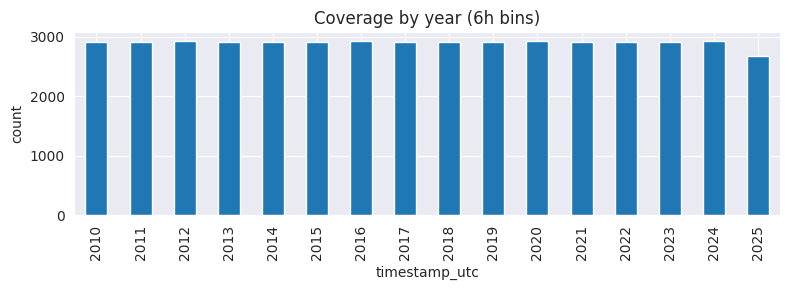

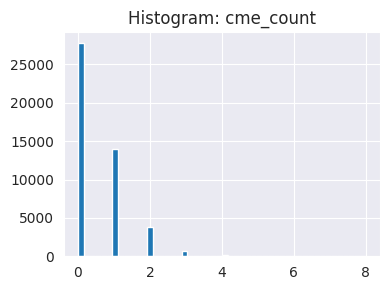

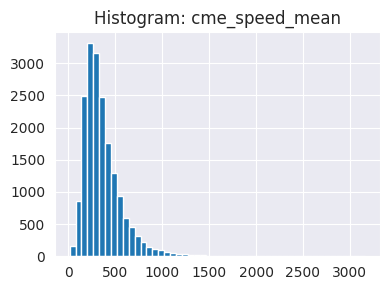

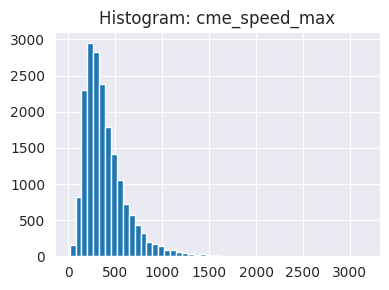

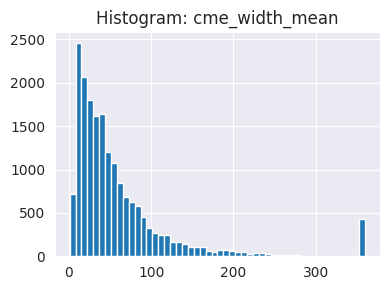

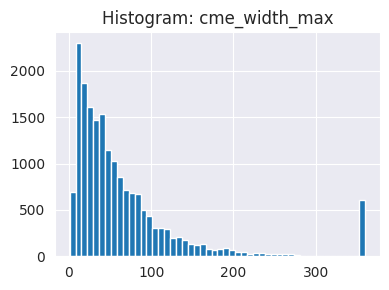

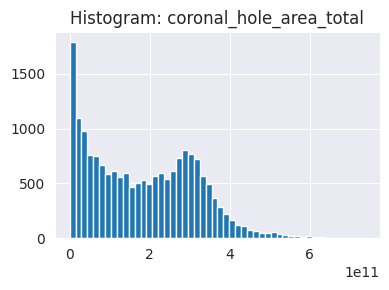

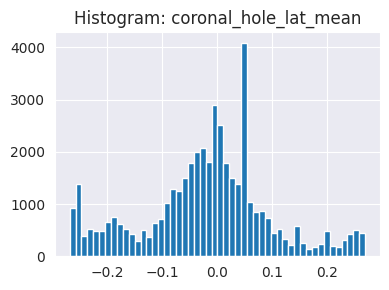

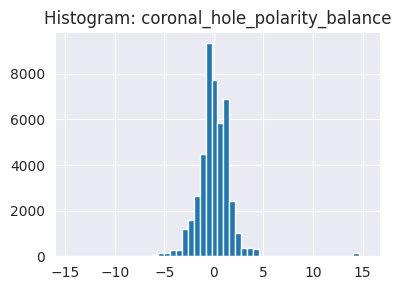

/tmp/ipykernel_93406/3742984462.py:40: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.set_index('timestamp_utc').resample('Y').mean(numeric_only=True)


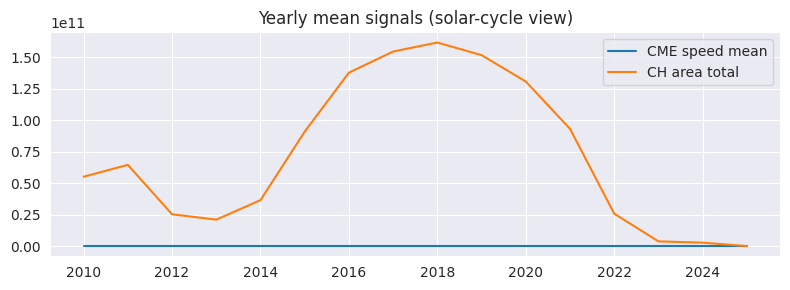

In [33]:
# Mini-EDA for solar-origin timeline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PATH = Path('../../Data/processed/solar_origin_features.parquet')
df = pd.read_parquet(PATH)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

# Coverage by year (solar-cycle inspection)
by_year = df['timestamp_utc'].dt.year.value_counts().sort_index()
plt.figure(figsize=(8,3))
by_year.plot(kind='bar')
plt.title('Coverage by year (6h bins)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# Histograms
hist_cols = [
    'cme_count', 'cme_speed_mean', 'cme_speed_max',
    'cme_width_mean', 'cme_width_max',
    'coronal_hole_area_total', 'coronal_hole_lat_mean',
    'coronal_hole_polarity_balance'
]

for col in hist_cols:
    if col not in df.columns:
        continue
    plt.figure(figsize=(4,3))
    series = df[col].dropna()
    if col in ['cme_speed_mean', 'cme_speed_max', 'cme_width_mean', 'cme_width_max', 'coronal_hole_area_total']:
        series = series[series > 0]
    plt.hist(series, bins=50)
    plt.title(f'Histogram: {col}')
    plt.tight_layout()
    plt.show()

# Yearly means (solar-cycle signal)
yearly = df.set_index('timestamp_utc').resample('Y').mean(numeric_only=True)
plt.figure(figsize=(8,3))
if 'cme_speed_mean' in yearly.columns:
    plt.plot(yearly.index.year, yearly['cme_speed_mean'], label='CME speed mean')
if 'coronal_hole_area_total' in yearly.columns:
    plt.plot(yearly.index.year, yearly['coronal_hole_area_total'], label='CH area total')
plt.title('Yearly mean signals (solar-cycle view)')
plt.legend()
plt.tight_layout()
plt.show()


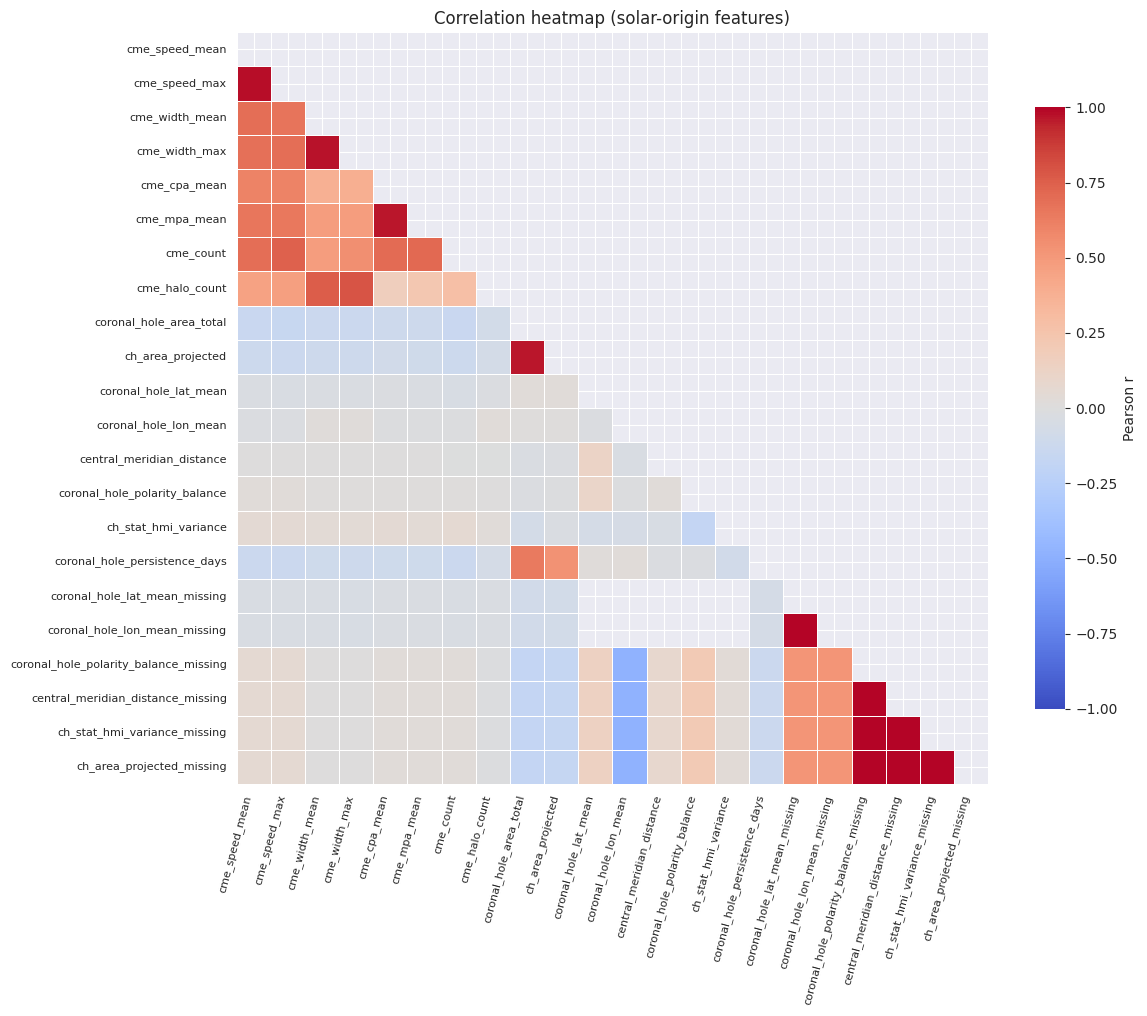

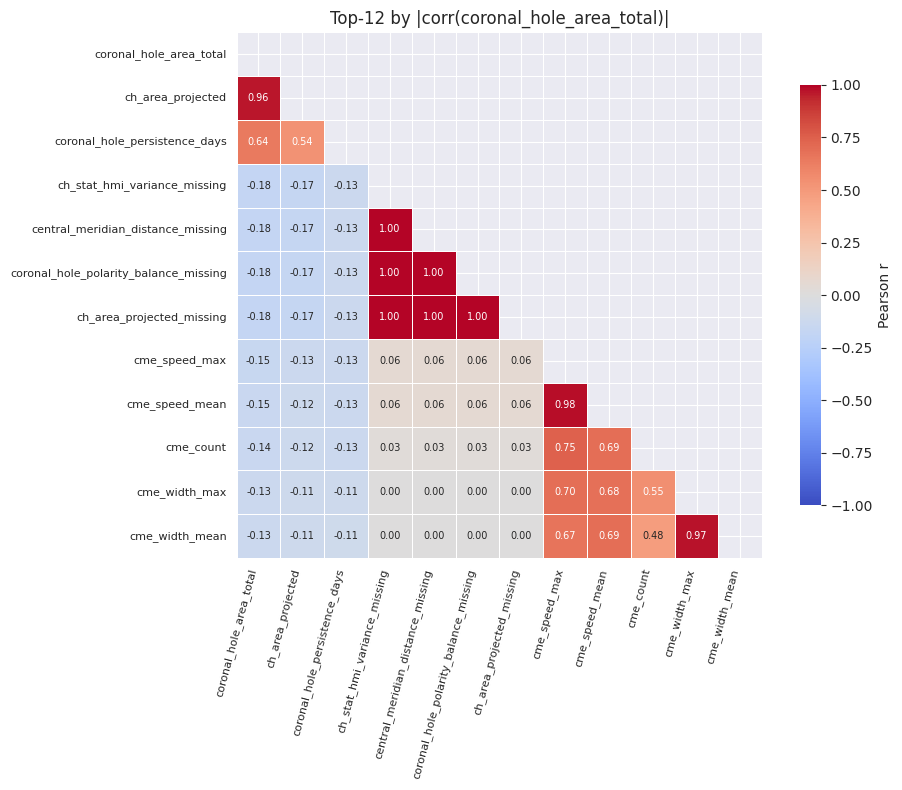

In [34]:
# Part 3 — Correlation & Relationships (solar-origin features)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

PATH = Path('../../Data/processed/solar_origin_features.parquet')
df = pd.read_parquet(PATH)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

# Correlation matrices
numeric_df = df.select_dtypes(include=[np.number]).copy()
corr = numeric_df.corr()

# 1) Full correlation heatmap (lower triangle)
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(
  corr,
  mask=mask,
  cmap='coolwarm',
  center=0,
  vmin=-1, vmax=1,
  square=True,
  linewidths=0.6,
  annot=False,
  cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
)
ax.set_title('Correlation heatmap (solar-origin features)')
ax.tick_params(axis='x', rotation=75, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
for lbl in ax.get_xticklabels():
  lbl.set_horizontalalignment('right')
plt.tight_layout()
plt.show()

# 2) Top-K by |corr(target)|
target = 'coronal_hole_area_total'  # change if needed
k = 12
if target in corr.columns:
  rank = corr[target].abs().sort_values(ascending=False)
  cols = [target] + [c for c in rank.index if c != target][: k - 1]
  corr_k = corr.loc[cols, cols]

  plt.figure(figsize=(10, 8))
  mask = np.triu(np.ones_like(corr_k, dtype=bool))
  ax = sns.heatmap(
    corr_k,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.6,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
  )
  ax.set_title(f'Top-{k} by |corr({target})|')
  ax.tick_params(axis='x', rotation=75, labelsize=8)
  ax.tick_params(axis='y', rotation=0, labelsize=8)
  for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
  plt.tight_layout()
  plt.show()
else:
  print(f'No target column {target} found in data.')
